In [1]:
import os
os.chdir("../")
configs_file = "train_cvit"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
jax.config.update("jax_default_matmul_precision", "highest")
# jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

from burgers.configs import load_configs
configs = load_configs(configs_file)


from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

In [3]:
data = jnp.load("data/burgers/burgers_training.npz")
x = data["x"]
y = data["y"]
t = data["times"]
solutions = data["solutions"]  # (num_times, num_points)
xx, yy = jnp.meshgrid(x, y, indexing="xy") # (H, W)


In [4]:

solutions = rearrange(solutions, "b t c y x -> b t y x c",)
solutions.shape

(256, 101, 64, 64, 2)

In [5]:

def sample_points(key, t, y, x, solutions, num_samples,):
    # solutions: (B, T, H, W, C)
    B, T, H, W, C = solutions.shape
    total = T * H * W
    
    # sample num_samples coordinates from the spatio-temporal grid of size T x H x W for each input function
    idx = jax.random.randint(key, (num_samples,), 0, total)
    t_idx, y_idx, x_idx = jnp.unravel_index(idx, (T, H, W)) # (num_samples,)
    
    values = solutions[:, t_idx, y_idx, x_idx, :] # (B, num_samples, C)
    t_data = t[t_idx] # (num_samples,)
    x_data = jnp.stack([x[x_idx], y[y_idx]], axis=-1) # (num_samples, 2)
    return t_data, x_data, values



t_data, x_data, values = sample_points(jax.random.PRNGKey(0), t, y, x, solutions, num_samples=100)
t_data.shape, x_data.shape, values.shape

((100,), (100, 2), (256, 100, 2))

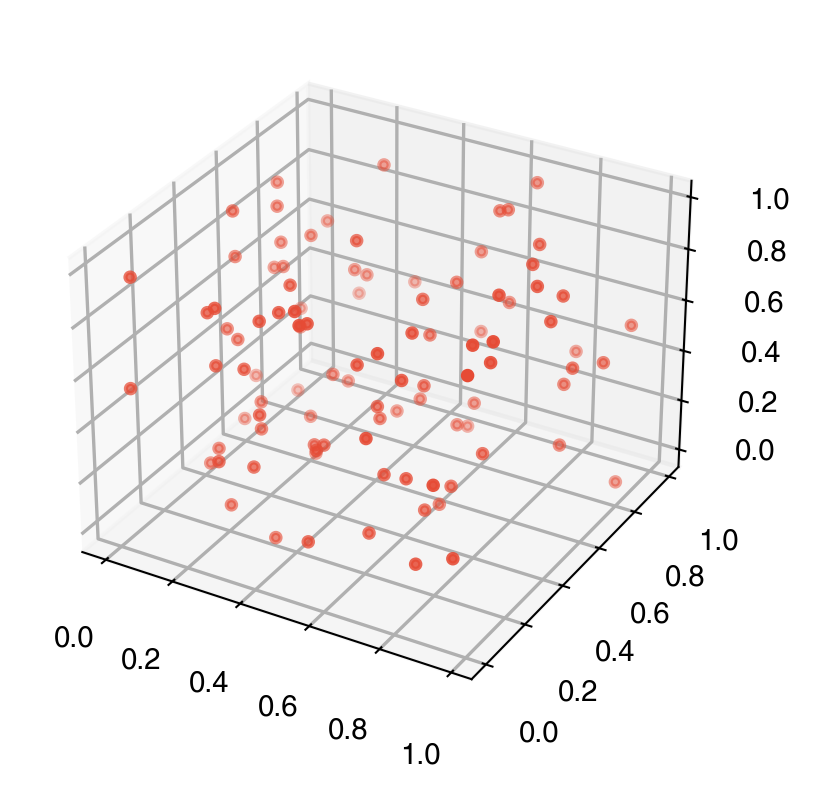

In [6]:
fig, ax = plt.subplots(figsize=(4, 3),subplot_kw={"projection": "3d"})
ax.scatter(x_data[:, 0], x_data[:, 1], t_data,  s=5)

(array([7., 6., 7., 8., 3., 8., 3., 4., 3., 6., 3., 4., 5., 9., 6., 2., 6.,
        3., 1., 6.]),
 array([0.        , 0.04921875, 0.0984375 , 0.14765626, 0.19687501,
        0.24609375, 0.29531252, 0.34453127, 0.39375001, 0.44296876,
        0.4921875 , 0.54140627, 0.59062505, 0.63984376, 0.68906254,
        0.73828125, 0.78750002, 0.8367188 , 0.88593751, 0.93515629,
        0.984375  ]),
 <BarContainer object of 20 artists>)

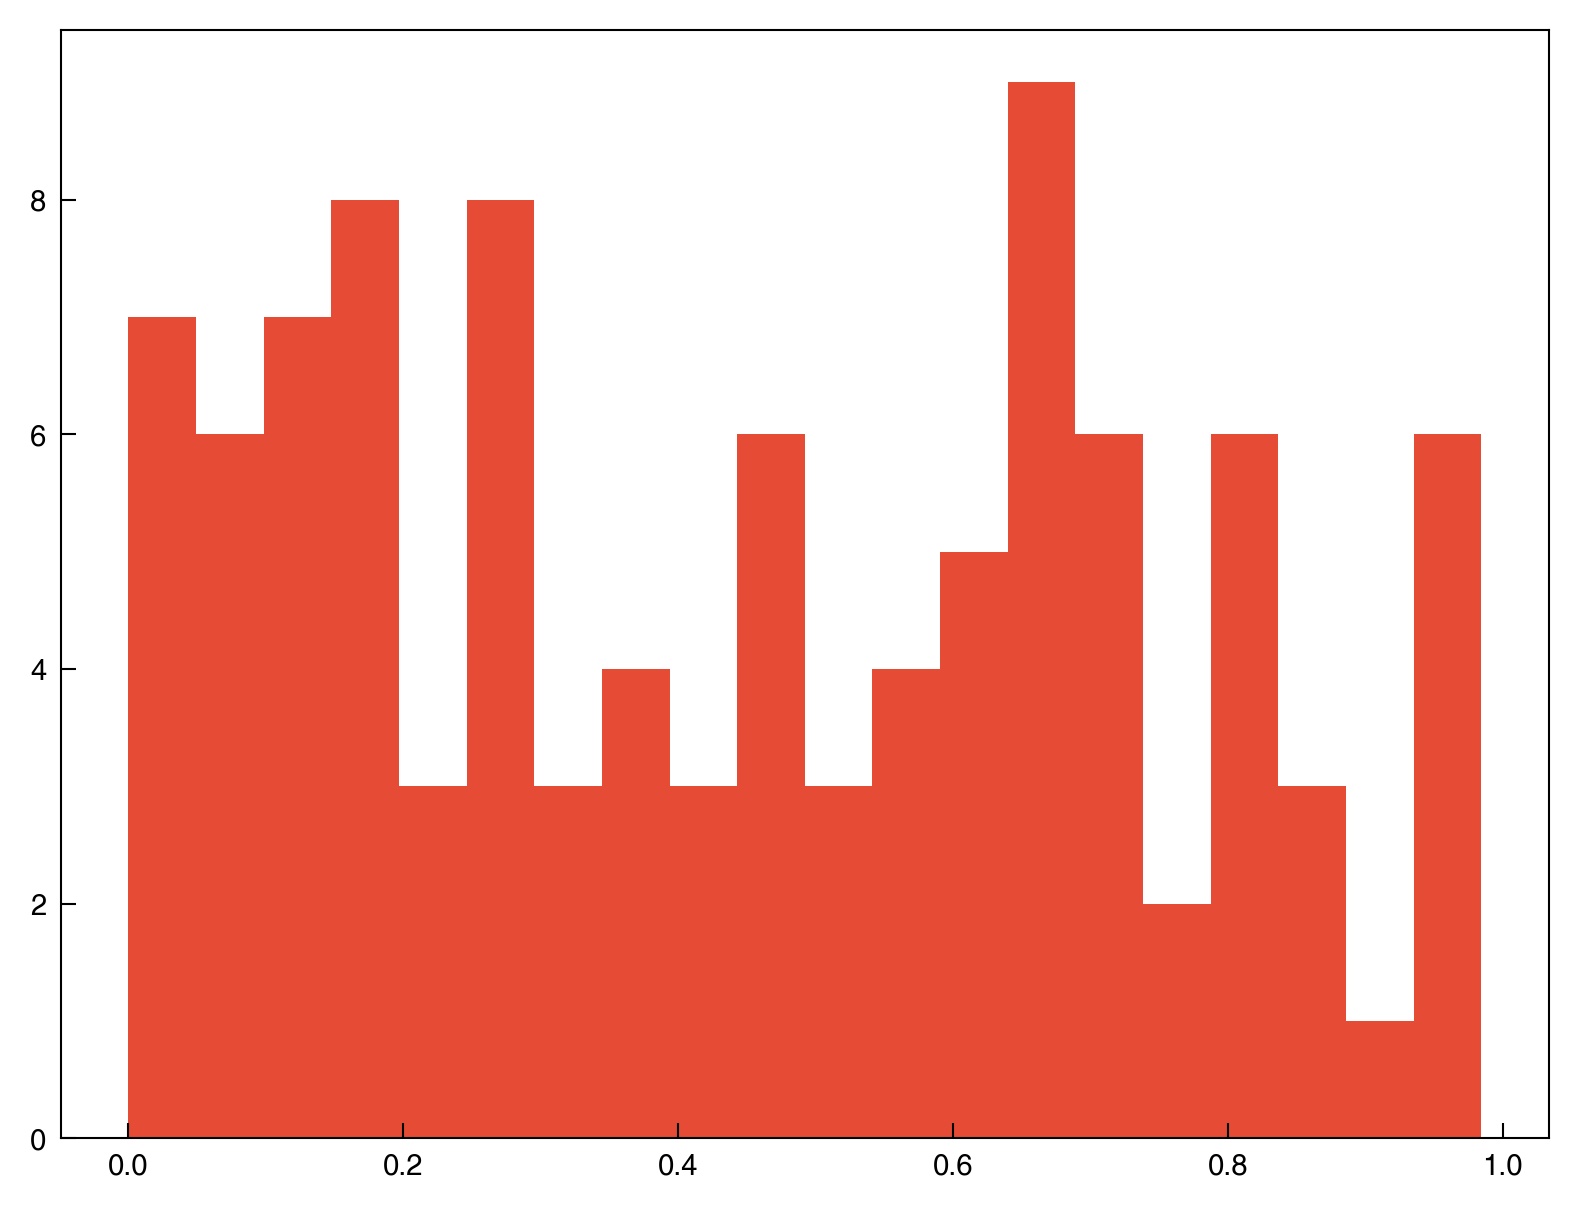

In [16]:
plt.hist(x_data[:, 1], bins=20)